### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data (5 years)

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("AAPL")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-29,118.233307,119.392364,117.590474,118.486548,80819200
1,2021-03-30,116.782059,117.269056,115.769103,116.986597,85671900
2,2021-03-31,118.973557,120.307926,117.999561,118.486559,118323800
3,2021-04-01,119.801453,120.950768,119.304713,120.444293,75089100
4,2021-04-05,122.626060,122.879301,119.869651,120.648850,88651200


### Plot stock data

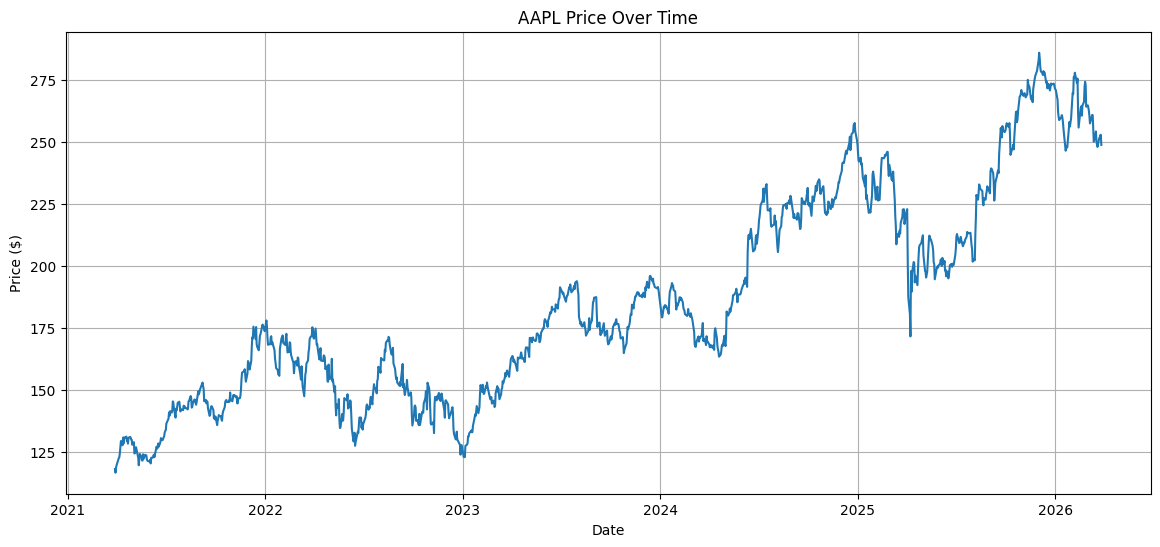

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.show()

### Plot the 9, 21, and 100 EMAs

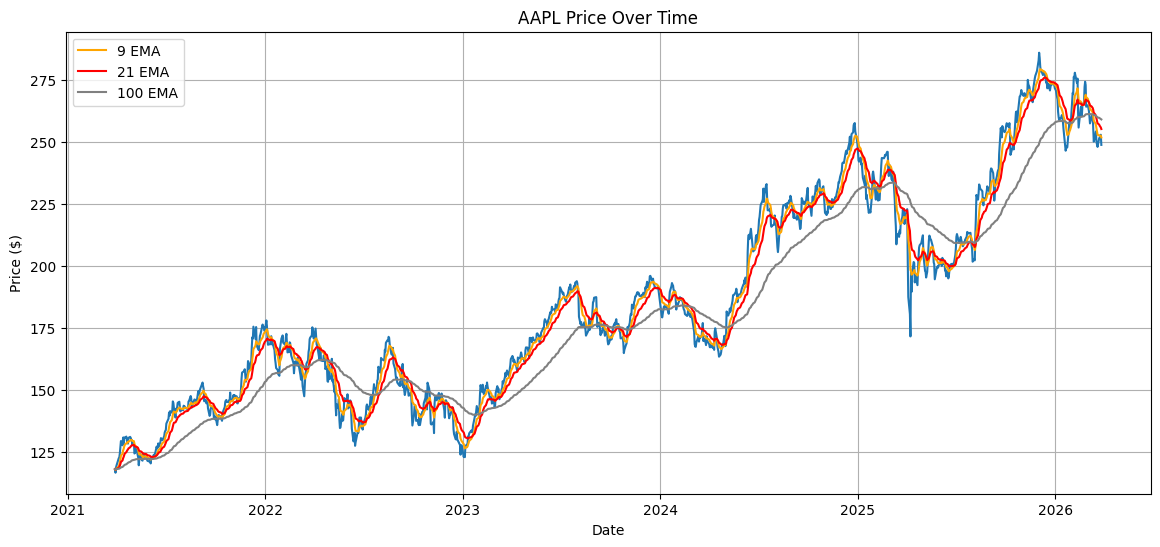

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Create 21 EMA distance, 21 EMA slope, and daily % return features

In [6]:
df["dist_ema21"] = (df["Close"] - df["ema21"]) / df["ema21"]
df["slope_ema21"] = df["ema21"].diff()
df["return"] = df["Close"].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-29,118.233307,119.392364,117.590474,118.486548,80819200,118.233307,118.233307,118.233307,0.000000,NaN,NaN
1,2021-03-30,116.782059,117.269056,115.769103,116.986597,85671900,117.943057,118.101375,118.204569,-0.011171,-0.131932,-0.012274
2,2021-03-31,118.973557,120.307926,117.999561,118.486559,118323800,118.149157,118.180664,118.219797,0.006709,0.079289,0.018766
3,2021-04-01,119.801453,120.950768,119.304713,120.444293,75089100,118.479616,118.328009,118.251117,0.012452,0.147344,0.006959
4,2021-04-05,122.626060,122.879301,119.869651,120.648850,88651200,119.308905,118.718741,118.337749,0.032912,0.390732,0.023577


In [7]:
df = df.dropna().reset_index(drop=True)
df.drop(columns=["High", "Low", "Open", "Volume"], inplace=True)
df.head()

,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782059,117.943057,118.101375,118.204569,-0.011171,-0.131932,-0.012274
1,2021-03-31,118.973557,118.149157,118.180664,118.219797,0.006709,0.079289,0.018766
2,2021-04-01,119.801453,118.479616,118.328009,118.251117,0.012452,0.147344,0.006959
3,2021-04-05,122.626060,119.308905,118.718741,118.337749,0.032912,0.390732,0.023577
4,2021-04-06,122.927994,120.032723,119.101400,118.428645,0.032129,0.382659,0.002462


### Use a 70/10/20 train/validation/test split

In [8]:
df.shape

(1255, 8)

In [9]:
train_end = int(len(df) * 0.7)
val_end = int(len(df) * 0.8)

train = df[:train_end]
val = df[train_end:val_end]
test = df[val_end:]

In [10]:
print(train.shape)
train.head()

(878, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782059,117.943057,118.101375,118.204569,-0.011171,-0.131932,-0.012274
1,2021-03-31,118.973557,118.149157,118.180664,118.219797,0.006709,0.079289,0.018766
2,2021-04-01,119.801453,118.479616,118.328009,118.251117,0.012452,0.147344,0.006959
3,2021-04-05,122.626060,119.308905,118.718741,118.337749,0.032912,0.390732,0.023577
4,2021-04-06,122.927994,120.032723,119.101400,118.428645,0.032129,0.382659,0.002462


In [11]:
print(val.shape)
val.head()

(126, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
878,2024-09-25,224.892685,223.540166,222.341682,211.404977,0.011473,0.255100,-0.004398
879,2024-09-26,226.035202,224.039173,222.677456,211.694685,0.015079,0.335775,0.005080
880,2024-09-27,226.303421,224.492023,223.007089,211.983967,0.014781,0.329633,0.001187
881,2024-09-30,231.479431,225.889504,223.777302,212.370015,0.034419,0.770213,0.022872
882,2024-10-01,224.733749,225.658353,223.864252,212.614842,0.003884,0.086950,-0.029142


In [12]:
print(test.shape)
test.head()

(251, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
1004,2025-03-28,216.954422,219.220001,222.442763,229.400311,-0.024673,-0.548834,-0.026580
1005,2025-03-31,221.166061,219.609213,222.326699,229.237256,-0.005220,-0.116064,0.019413
1006,2025-04-01,222.221466,220.131664,222.317132,229.098330,-0.000430,-0.009567,0.004772
1007,2025-04-02,222.918427,220.689016,222.371796,228.975955,0.002458,0.054663,0.003136
1008,2025-04-03,202.308258,217.012865,220.547838,228.447882,-0.082701,-1.823958,-0.092456


### Normalize the dataset

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
features = ["Close", "ema21", "dist_ema21", "slope_ema21", "return"]
target = "Close"

# MinMaxScaler has default param feature_range=(0,1)
features_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Training data
train_features = train[features]
train_target = train[[target]]

# Validation data
val_features = val[features]
val_target = val[[target]]

# Testing data
test_features = test[features]
test_target = test[[target]]

# Scale training data
train_features_scaled = features_scaler.fit_transform(train_features)
train_target_scaled = target_scaler.fit_transform(train_target)

window = 60

# Scale validation data
prev_window_val = train_features.tail(window)
val_features = pd.concat([prev_window_val, val_features], ignore_index=True)
val_features_scaled = features_scaler.transform(val_features)
val_target_scaled = target_scaler.transform(val_target)

# Scale testing data
# We take data from val_features (and not train_features) because data needs to stay chronological
prev_window_test = val_features.tail(window)
test_features = pd.concat([prev_window_test, test_features], ignore_index=True)
test_features_scaled = features_scaler.transform(test_features)
test_target_scaled = target_scaler.transform(test_target)

print(train_features_scaled.shape)
print(val_features_scaled.shape)
print(test_features_scaled.shape)

print(train_target_scaled.shape)
print(val_target_scaled.shape)
print(test_target_scaled.shape)

(878, 5)
(186, 5)
(311, 5)
(878, 1)
(126, 1)
(251, 1)


In [15]:
print(train_features_scaled[:3])
print(train_features_scaled[-3:])

[[0.         0.         0.44159124 0.40206616 0.31428172]
 [0.0188539  0.00075792 0.53073762 0.46312144 0.52450421]
 [0.02597646 0.00216637 0.55937106 0.48279339 0.4445398 ]]
[[0.94573876 0.98721168 0.61738705 0.59434792 0.37758513]
 [0.93095253 0.9903522  0.57117072 0.53517081 0.3460687 ]
 [0.93864456 0.99398417 0.58258637 0.55003224 0.42432502]]


In [16]:
print(test_features_scaled[:3])
print(test_features_scaled[-3:])

[[1.15323954 1.23381388 0.57098195 0.54581029 0.30758332]
 [1.13800922 1.23545037 0.53179612 0.48968921 0.34961188]
 [1.0817933  1.23125984 0.40876454 0.31348144 0.21972632]]
[[1.16864119 1.31942215 0.42892172 0.33868082 0.42378706]
 [1.17096409 1.31660477 0.43984867 0.35500523 0.40465027]
 [1.13577702 1.31048935 0.37229796 0.25527313 0.2878782 ]]


In [17]:
print(train_target_scaled[:3])
print(train_target_scaled[-3:])

[[0.        ]
 [0.0188539 ]
 [0.02597646]]
[[0.94573876]
 [0.93095253]
 [0.93864456]]


In [18]:
print(test_target_scaled[:3])
print(test_target_scaled[-3:])

[[0.86180306]
 [0.89803665]
 [0.90711651]]
[[1.16864119]
 [1.17096409]
 [1.13577702]]


### Create training sequences

In [19]:
x_train = []
y_train = []

# For each timestamp (row) x, grab the #(window) timestamps before it and add them as a singular element to x_train. Add timestamp x as an element to y_train.
for i in range(window, train_features_scaled.shape[0]):
    x_train.append(train_features_scaled[i - window : i])
    y_train.append(train_target_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(818, 60, 5)
(818,)


### Create validation sequences

In [20]:
x_val = []
y_val = []

for i in range(window, val_features_scaled.shape[0]):
    x_val.append(val_features_scaled[i - window : i])
    y_val.append(val_target_scaled[i - window, 0])

x_val = np.array(x_val)
y_val = np.array(y_val)

print(x_val.shape)
print(y_val.shape)

(126, 60, 5)
(126,)


### Create testing sequences

In [21]:
x_test = []
y_test = []

for i in range(window, test_features_scaled.shape[0]):
    x_test.append(test_features_scaled[i - window : i])
    y_test.append(test_target_scaled[i - window, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(251, 60, 5)
(251,)


### Build LSTM model

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [23]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=32))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [24]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

early_stopping = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, validation_data=(x_val, y_val), shuffle=False, callbacks=[early_stopping])

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0353 - mean_absolute_error: 0.1479 - val_loss: 0.0065 - val_mean_absolute_error: 0.0662
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0672 - mean_absolute_error: 0.2176 - val_loss: 0.0917 - val_mean_absolute_error: 0.2964
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0278 - mean_absolute_error: 0.1436 - val_loss: 0.0264 - val_mean_absolute_error: 0.1511
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0131 - mean_absolute_error: 0.0928 - val_loss: 0.0094 - val_mean_absolute_error: 0.0751
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0069 - mean_absolute_error: 0.0640 - val_loss: 0.0060 - val_mean_absolute_error: 0.0595
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0060 - mean_absolute_error: 0.0586 - val_loss: 0.0043 - val_mean_absolute_error: 0.0507
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0053 - mean_absolute_error: 0.0564 - v

### Make prediction

In [26]:
y_pred = model.predict(x_test)
print(y_pred.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
(251, 1)


In [27]:
print(y_test[:10])

[0.86180306 0.89803665 0.90711651 0.9131126  0.73579916 0.60893869
 0.54966289 0.47222738 0.69862329 0.62641315]


In [28]:
print(y_pred[:10])

[[0.906615  ]
 [0.87122107]
 [0.8876107 ]
 [0.8970456 ]
 [0.90516007]
 [0.78944314]
 [0.67342174]
 [0.59107554]
 [0.5124748 ]
 [0.64017785]]


### Plot prediction

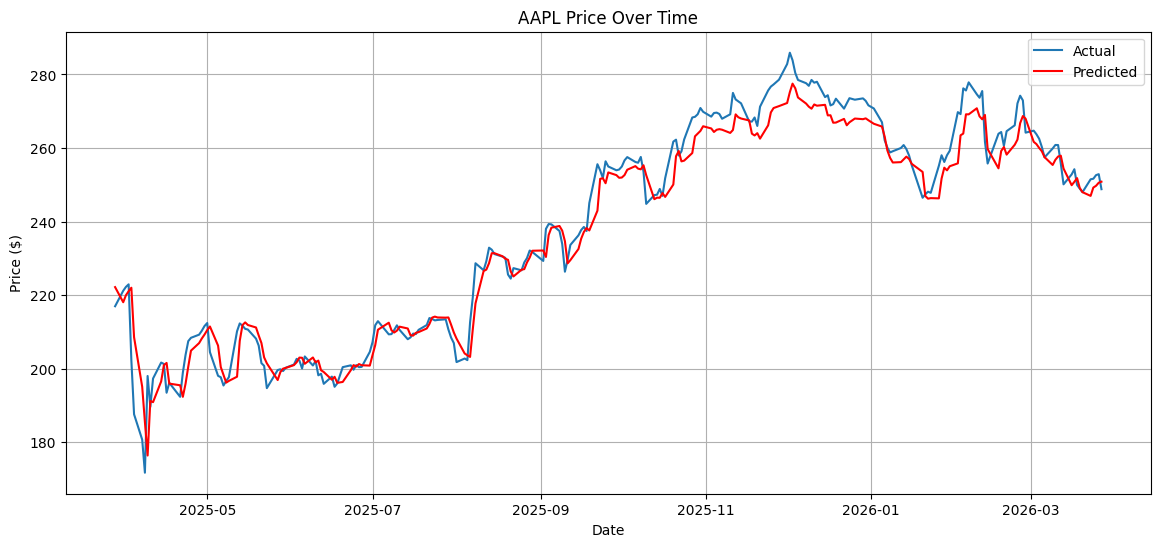

In [29]:
y_pred_prices = target_scaler.inverse_transform(y_pred).flatten()
y_test_prices = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual")
plt.plot(test["Date"], y_pred_prices, label="Predicted", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.legend()